In [81]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

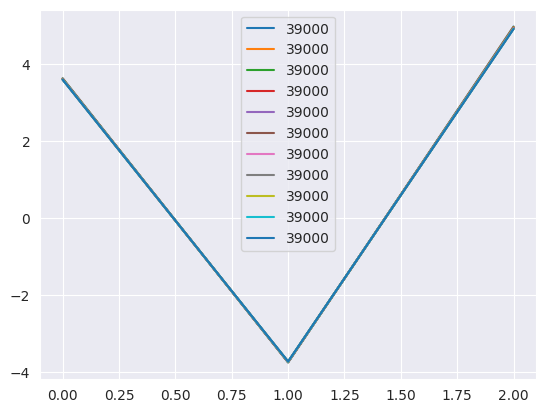

In [82]:
for idx in range(n):
    plt.plot(np.mean(PKLs[idx]['res'][0][-1], axis=[0, 1]).T, label=np.prod(PKLs[idx]['res'][0][-1].shape[:2]))
plt.legend()

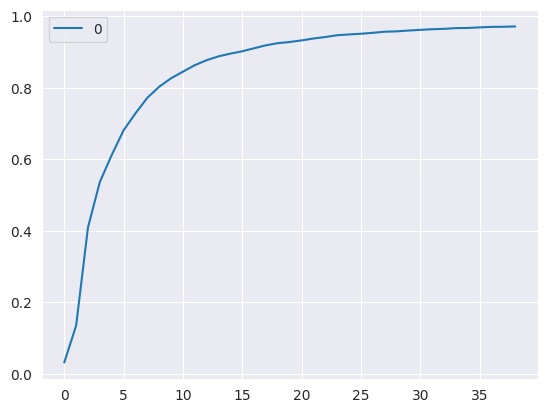

In [83]:
for idx in range(n):
    weights = np.exp(PKLs[idx]['res'][1][:,:,].reshape((*PKLs[idx]['res'][1].shape[:2], -1)))
    num_particles = weights.shape[-1]
    plt.plot(np.mean(1/np.sum(np.square(weights), axis=-1).T/num_particles, axis=-1), label=idx)
plt.legend()

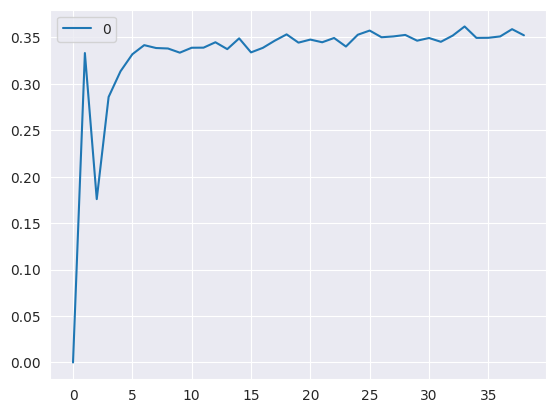

In [84]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][3][0].mean(axis=[1, 2]), label=idx)
plt.legend()

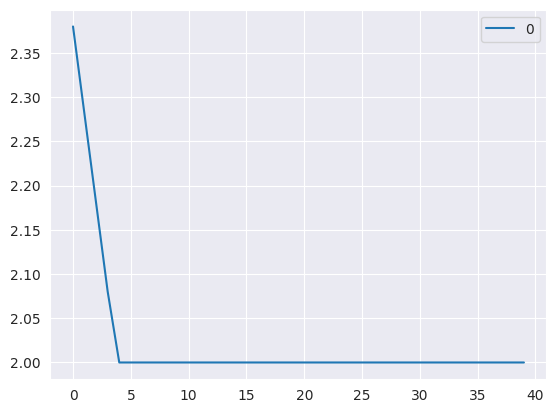

In [85]:
for idx in range(n):
    plt.plot(PKLs[idx]['res'][2][...,0].mean(axis=0), label=idx)
plt.legend()

In [86]:
PKLs[0]['res'][2][...,0].shape

(5, 40)

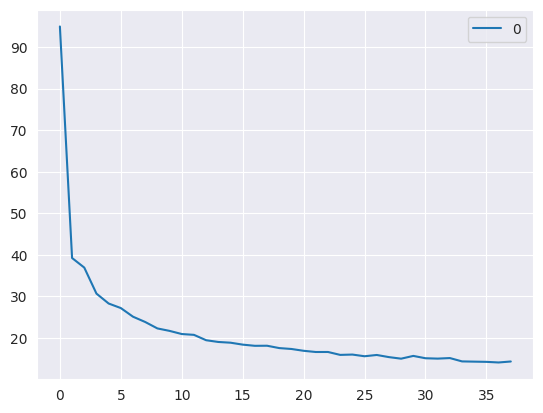

In [87]:
for idx in range(n):
    plt.plot(np.sum(np.square(np.diff(PKLs[idx]['res'][0], axis=-2, n=5)), axis=-1).mean(axis=-1).mean(axis=-1).mean(axis=0)[1:], label=idx)
plt.legend()

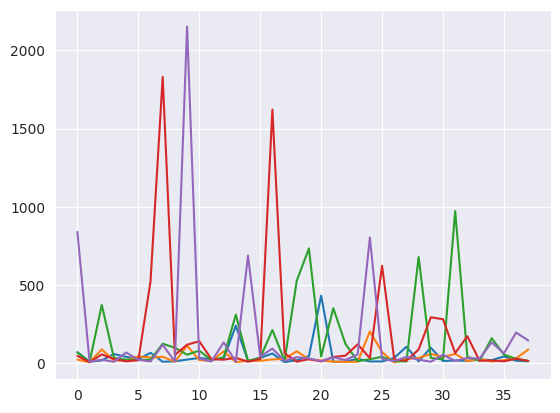

In [88]:
import jax
import jax.numpy as jnp
is_weights = jnp.exp(PKLs[0]['res'][4])
is_weights = is_weights.reshape(is_weights.shape[:2] + (-1,))
is_weights_shape = is_weights.shape
is_weights = is_weights.reshape(-1, is_weights.shape[-1])
var_over_mean_sq = jax.vmap(lambda s: jnp.var(s)/jnp.mean(s)**2, in_axes=(0))(is_weights)
var_over_mean_sq = var_over_mean_sq.reshape(is_weights_shape[:2])
plt.plot(var_over_mean_sq.T)

In [37]:
is_weights.shape

(5, 38, 10000)

In [44]:
jax.vmap(lambda s: jnp.var(s)/jnp.mean(s)**2, in_axes=((0,1)))(is_weights)

ValueError: vmap in_axes must be an int, None, or a tuple of entries corresponding to the positional arguments passed to the function, but got len(in_axes)=2, len(args)=1